In [1]:
import os
import pathlib
from collections import defaultdict

import json
from typing import List, Literal

from tqdm import trange

import numpy as np
import pandas as pd

import scanpy as sc
import anndata

import torch
import torch.nn as nn

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.predict import get_prediction
from scLEMBAS.metrics import distances 


sys.path.insert(1, '../../.')
from McCauley_utils import initialize_mod_and_trainer, all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split

sys.path.insert(1, './.')
from pruning_utils import load_model, get_edge_weights


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/us

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

# Get model results

In [4]:
bn_weight_l2 = 0#1e-1 # 1e-4 # 1e-7
bn_weight_l1 = 1e-3 #0

In [11]:
learned_weights = []
train_stats = []
eval_stats = []
loss_res = defaultdict(list)

fn = os.path.join(data_path, 'processed', '{}_pruning_res_all.pickle'.format(author))

if not os.path.isfile(fn):
    for fold in range(5):

        split = get_split(fold = fold, author = author)

        test_conds = split['test_conds']
        train_barcodes = split['train_barcodes']
        test_barcodes = split['test_barcodes']

        ctrl_conds = sorted(set([tc.split('^')[0] + '^' + ctrl_pert for tc in test_conds]))
        ctrl_mask = tf_adata.obs.loc[train_barcodes, 'condition'].isin(ctrl_conds).values
        ctrl_cells = list(np.array(train_barcodes)[ctrl_mask])


        for ensemble_idx in trange(5):
    #         try:

            # load
            mod, trainer, train_stats_df, eval_df = load_model(fold = fold, ensemble_idx = ensemble_idx, 
                          bn_weight_l2 = bn_weight_l2, bn_weight_l1 = bn_weight_l1,
                          from_trainer = False)

            # RESULTS
            stochastic_edge_weights, real_edge_weights = get_edge_weights(mod)

            tf_adata_predicted = get_prediction(
                mod = mod,
                train_cells = train_barcodes,
                test_cells = test_barcodes, 
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert, 
                counterfactual = 'perturbation', # counterfactual from tests
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False, 
                max_cells = int(5e3), 
                return_full = False, 
                stim_label_map = None, # special use case for Kang
            )
            emd_loss = distances.get_EMD_loss(tf_adata, tf_adata_predicted)['Mean EMD Loss']
            loss_res['loss'].append(emd_loss)
            loss_res['fold'].append(fold)
            loss_res['ensemble_idx'].append(ensemble_idx)


            # formatting
            learned_vals = pd.DataFrame(data= {
                'weights': np.concatenate([stochastic_edge_weights.numpy(), real_edge_weights.numpy()]), 
                'edge_type': ['random']*stochastic_edge_weights.size()[0] + ['real']*real_edge_weights.size()[0]
            })

            for df in [train_stats_df, eval_df, learned_vals]:
                df['fold'] = fold
                df['ensemble_idx'] = ensemble_idx

            # storing
            learned_weights.append(learned_vals)
            train_stats.append(train_stats_df)
            eval_stats.append(eval_df)
    #             mod_dict['fold{}_ensemble{}'.format(fold, ensemble_idx)] = mod
            del mod, trainer
    #         except:
    #             pass

    learned_weights = pd.concat(learned_weights)

    train_stats_df = pd.concat(train_stats)
    eval_stats_df = pd.concat(eval_stats)
    lr_stochastic = pd.DataFrame(loss_res)


    all_results = {
        "learned_weights": learned_weights,
        "train_stats_df": train_stats_df,
        "eval_stats_df": eval_stats_df,
        "lr_stochastic": lr_stochastic,
    }

    io.write_pickled_object(all_results, fn)


else:
    all_results = io.read_pickled_object(fn)

    learned_weights = all_results["learned_weights"]
    train_stats_df = all_results["train_stats_df"]
    eval_stats_df = all_results["eval_stats_df"]
    lr_stochastic = all_results["lr_stochastic"]

    learned_weights.edge_type = pd.Categorical(learned_weights.edge_type, 
                                              categories = ['real', 'random'], 
                                               ordered = True
                                              )

    
learned_weights.edge_type = pd.Categorical(learned_weights.edge_type, 
                                          categories = ['real', 'random'], 
                                           ordered = True
                                          )

# CDF visualization

In [12]:
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 15,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
)

In [13]:
def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

def cohens_d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    
    nx = len(x)
    ny = len(y)
    
    mean_x = x.mean()
    mean_y = y.mean()
    
    var_x = x.var(ddof=1)
    var_y = y.var(ddof=1)
    
    pooled_std = np.sqrt(((nx - 1) * var_x + (ny - 1) * var_y) / (nx + ny - 2))
    
    return (mean_x - mean_y) / pooled_std


def compute_cdf(x, log_transform: bool = False):
    x = np.asarray(x)
    if log_transform: 
        x = np.log(x)
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1, dtype=float) / len(x_sorted)
    return x_sorted, y

log_cdf_visual = True
weights_percentile_min = 0.75 # helps to zoom in on visual -- set to None or 0 if want to visualize everything
ymin_scaler = 1.2 # 1 to get the corresponding 75th percentile value

For CDF visualization, ensembles are pooled across fold. For residual statistics, CDFs are retained at the individual level.

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


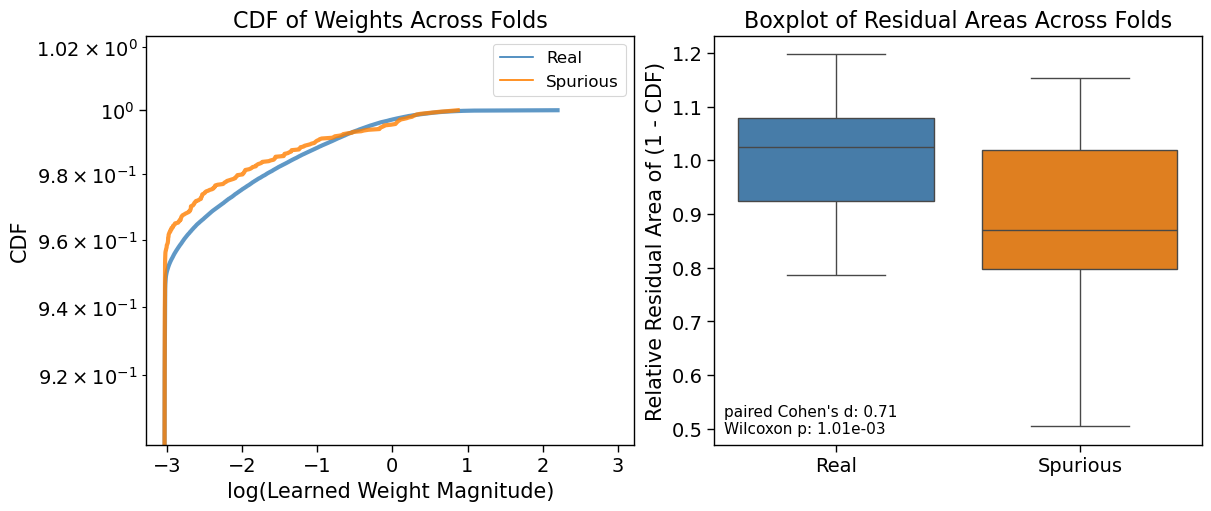

In [19]:
# -------------------- SETUP --------------------
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), constrained_layout=True)

stoch_color = sns.color_palette('Set1')[4]
real_color = sns.color_palette('Set1')[1]

real_mask = (learned_weights.edge_type == 'real')

# -------------------- CDF PANEL --------------------
j = 0

# # CDF visualization: per-model
# for fold in range(5):
#     fold_mask = (learned_weights.fold == fold)
#     for ensemble_idx in range(5):
#         ensemble_mask = (learned_weights.ensemble_idx == ensemble_idx)
        
#         x_stoch, y_stoch = compute_cdf(learned_weights[~real_mask & fold_mask & ensemble_mask].weights.values, 
#                                        log_transform = log_cdf_visual)
#         x_real, y_real = compute_cdf(learned_weights[real_mask & fold_mask & ensemble_mask].weights.values, 
#                                      log_transform = log_cdf_visual)
        
#         ax[j].plot(x_real, y_real, color=real_color, alpha=0.3, linewidth=1, zorder=1)
#         ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.3, linewidth=1, zorder=1)

# # CDF visualization: per-fold
# for fold in range(5):
#     fold_mask = (learned_weights.fold == fold)

#     x_stoch, y_stoch = compute_cdf(learned_weights[fold_mask & ~real_mask].weights.values, log_transform = log_cdf_visual)
#     x_real, y_real = compute_cdf(learned_weights[fold_mask & real_mask].weights.values, log_transform = log_cdf_visual)

#     ax[j].plot(x_real, y_real, color=real_color, alpha=0.3, linewidth=1, zorder=1)
#     ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.3, linewidth=1, zorder=1)

# CDF visualization: all
x_stoch, y_stoch = compute_cdf(learned_weights[~real_mask].weights.values, log_transform = log_cdf_visual)
x_real, y_real = compute_cdf(learned_weights[real_mask].weights.values, log_transform = log_cdf_visual)
ax[j].plot(x_real, y_real, color=real_color, alpha=0.8, linewidth=3, zorder=2, label="Real")
ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.8, linewidth=3, zorder=2, label="Spurious")

# zoom in on relevant regime
# ax[j].set_ylim(0.9, 1.01)
# ax[j].set_xlim(-3.2, 3)

if weights_percentile_min is not None and weights_percentile_min > 0:
    weight_vals = np.log(learned_weights.weights) if log_cdf_visual else learned_weights.weights
    percentile_val = weight_vals.quantile(weights_percentile_min)
    
    _, xmax = ax[j].get_xlim()
    _, ymax = ax[j].get_ylim()
    
    xmin = percentile_val
    
    x_sorted, y_filtered = compute_cdf(learned_weights.weights.values,log_transform=log_cdf_visual)
    ymin = y_filtered[np.searchsorted(x_sorted, percentile_val, side='left')] * ymin_scaler
    
    ax[j].set_ylim(ymin, ymax*0.975)
    ax[j].set_xlim(xmin, xmax*0.975)


xlabel = "Learned Weight Magnitude" if not log_cdf_visual else "log(Learned Weight Magnitude)"
ax[j].set_xlabel(xlabel)
ax[j].set_ylabel("CDF")
ax[j].set_title("CDF of Weights Across Folds")
ax[j].set_yscale('log')

# clean legend (manual to avoid duplicates)
handles = [
    plt.Line2D([0], [0], color=real_color, label="Real"),
    plt.Line2D([0], [0], color=stoch_color, label="Spurious")
]
ax[j].legend(handles=handles)


# -------------------- BOXPLOT PANEL --------------------
j = 1

residuals_stochastic = []
residuals_real = []
# residual statistics
for fold in range(5):
    fold_mask = (learned_weights.fold == fold)
    for ensemble_idx in range(5):
        ensemble_mask = (learned_weights.ensemble_idx == ensemble_idx)
        
        x_stoch, y_stoch = compute_cdf(
            learned_weights[~real_mask & fold_mask & ensemble_mask].weights.values, log_transform = False
        )
        x_real, y_real = compute_cdf(
            learned_weights[real_mask & fold_mask & ensemble_mask].weights.values, log_transform = False
        )
        
        # residual areas
        area_stoc = np.trapz(1 - y_stoch, x_stoch)
        area_real = np.trapz(1 - y_real, x_real)

        residuals_stochastic.append(area_stoc)
        residuals_real.append(area_real)
        
# same if run on normalized or not
a = np.array(residuals_real)
b = np.array(residuals_stochastic)
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b, alternative = 'greater').pvalue



mean_real = np.mean(residuals_real)

df_box = pd.DataFrame({
    "value": np.concatenate([
        np.array(residuals_real) / mean_real, 
        np.array(residuals_stochastic) / mean_real,
    ]),
    "type": ["Real"] * len(residuals_real) + 
    ["Spurious"] * len(residuals_stochastic)
})

sns.boxplot(
    data=df_box,
    x="type",
    y="value",
    palette={"Spurious": stoch_color, "Real": real_color},
    ax=ax[j]
)

ax[j].set_ylabel("Relative Residual Area of (1 - CDF)")
ax[j].set_xlabel("")
ax[j].set_title("Boxplot of Residual Areas Across Folds")

annot_text = f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}"
ax[j].text(
    0.02, 0.02, annot_text,
    transform=ax[j].transAxes,   # use axes coords (0–1)
    ha='left',                  # right-align text
    va='bottom',                 # anchor to bottom
    fontsize=11,
)


for ext in ['svg', 'png']:
    fig.savefig(
        os.path.join(data_path, 'figures', '{}_self_pruning_cdf.{}'.format(author, ext)),
        dpi=1200 if ext == "png" else None,  # dpi matters for raster, not svg
        bbox_inches="tight",
        transparent=True
    )

plt.show()


In [29]:
weights_percentile_min = None #None # helps to zoom in on visual -- set to None or 0 if want to visualize everything
ymin_scaler = 1 # 1 to get the corresponding 75th percentile value

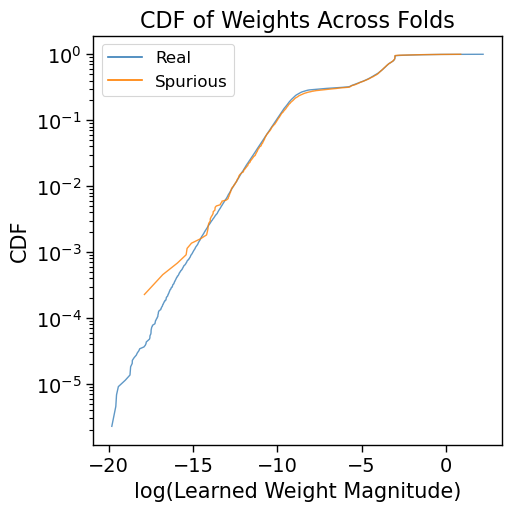

In [30]:
# -------------------- SETUP --------------------
n_cols = 1
fig, ax = plt.subplots(nrows=1, ncols=n_cols, figsize=(5, 5), constrained_layout=True)
if n_cols == 1:
    ax = [ax]

stoch_color = sns.color_palette('Set1')[4]
real_color = sns.color_palette('Set1')[1]

real_mask = (learned_weights.edge_type == 'real')

# -------------------- CDF PANEL --------------------
j = 0

# # CDF visualization: per-model
# for fold in range(5):
#     fold_mask = (learned_weights.fold == fold)
#     for ensemble_idx in range(5):
#         ensemble_mask = (learned_weights.ensemble_idx == ensemble_idx)
        
#         x_stoch, y_stoch = compute_cdf(learned_weights[~real_mask & fold_mask & ensemble_mask].weights.values, 
#                                        log_transform = log_cdf_visual)
#         x_real, y_real = compute_cdf(learned_weights[real_mask & fold_mask & ensemble_mask].weights.values, 
#                                      log_transform = log_cdf_visual)
        
#         ax[j].plot(x_real, y_real, color=real_color, alpha=0.3, linewidth=1, zorder=1)
#         ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.3, linewidth=1, zorder=1)

# # CDF visualization: per-fold
# for fold in range(5):
#     fold_mask = (learned_weights.fold == fold)

#     x_stoch, y_stoch = compute_cdf(learned_weights[fold_mask & ~real_mask].weights.values, log_transform = log_cdf_visual)
#     x_real, y_real = compute_cdf(learned_weights[fold_mask & real_mask].weights.values, log_transform = log_cdf_visual)

#     ax[j].plot(x_real, y_real, color=real_color, alpha=0.3, linewidth=1, zorder=1)
#     ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.3, linewidth=1, zorder=1)

# CDF visualization: all
x_stoch, y_stoch = compute_cdf(learned_weights[~real_mask].weights.values, log_transform = log_cdf_visual)
x_real, y_real = compute_cdf(learned_weights[real_mask].weights.values, log_transform = log_cdf_visual)
ax[j].plot(x_real, y_real, color=real_color, alpha=0.8, linewidth=1, zorder=2, label="Real")
ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.8, linewidth=1, zorder=2, label="Spurious")

# zoom in on relevant regime
# ax[j].set_ylim(0.9, 1.01)
# ax[j].set_xlim(-3.2, 3)

if weights_percentile_min is not None and weights_percentile_min > 0:
    weight_vals = np.log(learned_weights.weights) if log_cdf_visual else learned_weights.weights
    percentile_val = weight_vals.quantile(weights_percentile_min)
    
    _, xmax = ax[j].get_xlim()
    _, ymax = ax[j].get_ylim()
    
    xmin = percentile_val
    
    x_sorted, y_filtered = compute_cdf(learned_weights.weights.values,log_transform=log_cdf_visual)
    ymin = y_filtered[np.searchsorted(x_sorted, percentile_val, side='left')] * ymin_scaler
    
    ax[j].set_ylim(ymin, ymax*0.975)
    ax[j].set_xlim(xmin, xmax*0.975)


xlabel = "Learned Weight Magnitude" if not log_cdf_visual else "log(Learned Weight Magnitude)"
ax[j].set_xlabel(xlabel)
ax[j].set_ylabel("CDF")
ax[j].set_title("CDF of Weights Across Folds")
ax[j].set_yscale('log')

# clean legend (manual to avoid duplicates)
handles = [
    plt.Line2D([0], [0], color=real_color, label="Real"),
    plt.Line2D([0], [0], color=stoch_color, label="Spurious")
]
ax[j].legend(handles=handles)


plt.show()


# Check Loss Results and Training Curves

In [11]:
lr_no_stochastic = pd.read_csv(os.path.join(data_path, 'processed', '{}_scLEMBAS_model_losses.csv'.format(author)), 
                              index_col = 0)

mask = (
    (lr_no_stochastic.loss_type == 'EMD') &
    (lr_no_stochastic.remove_type == 'none') &
    (lr_no_stochastic.model_type == 'actual') &
    (lr_no_stochastic.space == 'feature'))
lr_no_stochastic = lr_no_stochastic[mask].copy()

lr_stochastic['model_type'] = 'scLEMBAS\n(standard training)'
lr_no_stochastic['model_type'] = 'scLEMBAS\n(trained with\nspurious edges)'
loss_res = pd.concat([lr_no_stochastic, lr_stochastic])
loss_res['model_type'] = pd.Categorical(
    loss_res['model_type'], 
    categories = ['scLEMBAS\n(standard training)', 'scLEMBAS\n(trained with\nspurious edges)'], 
    ordered = True
)

In [12]:
# identify all-zero columns (across all folds + ensembles)
loss_cols_main = [
    'train_loss_prediction', 'sign_reg_loss',
    'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
    'sn_param_reg_tot_loss', 'output_param_reg_tot_loss', 'vae_param_reg_loss',
    'global_bias_kl_divergence', 'contrastive_loss_total'
]
all_loss_cols = (
    loss_cols_main
    + ['total_train_loss_no_adverserial']
    + [
        'sn_param_reg_tot_loss',
        'sn_param_reg_weights_L2_loss',
        'sn_param_reg_weights_L1_loss',
        'sn_param_reg_weights_kl_divergence',
        'sn_param_reg_global_bias_L2_loss',
        'sn_param_reg_global_bias_L1_loss',
        'sn_param_reg_cat_bias_L2_loss',
        'sn_param_reg_cat_bias_L1_loss',
        'sn_param_reg_cat_bias_pert'
    ]
)

zero_cols = {
    col for col in all_loss_cols
    if col in train_stats_df.columns and np.all(train_stats_df[col].values == 0)
}

for col in ['sign_reg_loss']:
    train_stats_df[col] = train_stats_df[col].mask(
        (train_stats_df[col] == 0), 
        np.nan
    )
    
loss_map = {
    'train_loss_prediction': 'Prediction',
    'sign_reg_loss': 'Sign Reg.',
    'stability_reg_loss': 'Spectral Reg.',
    'uniform_reg_loss': 'Uniform Reg.',
    'contrastive_loss_total': 'Contrastive Reg.',
    'input_param_reg_loss': 'Input Param Reg.',
    'sn_param_reg_tot_loss': 'Signaling Network Param Reg.',
    'output_param_reg_tot_loss': 'Output Param Reg.',
    'vae_param_reg_loss': 'VAE Param Reg.',
    'global_bias_kl_divergence': r'$b_g$' + ' KL Div.',
    'total_train_loss_no_adverserial': 'Total (No Adversarial)'
}

def compute_mean(df, cols):
    return df.groupby("epoch")[cols].mean().reset_index()

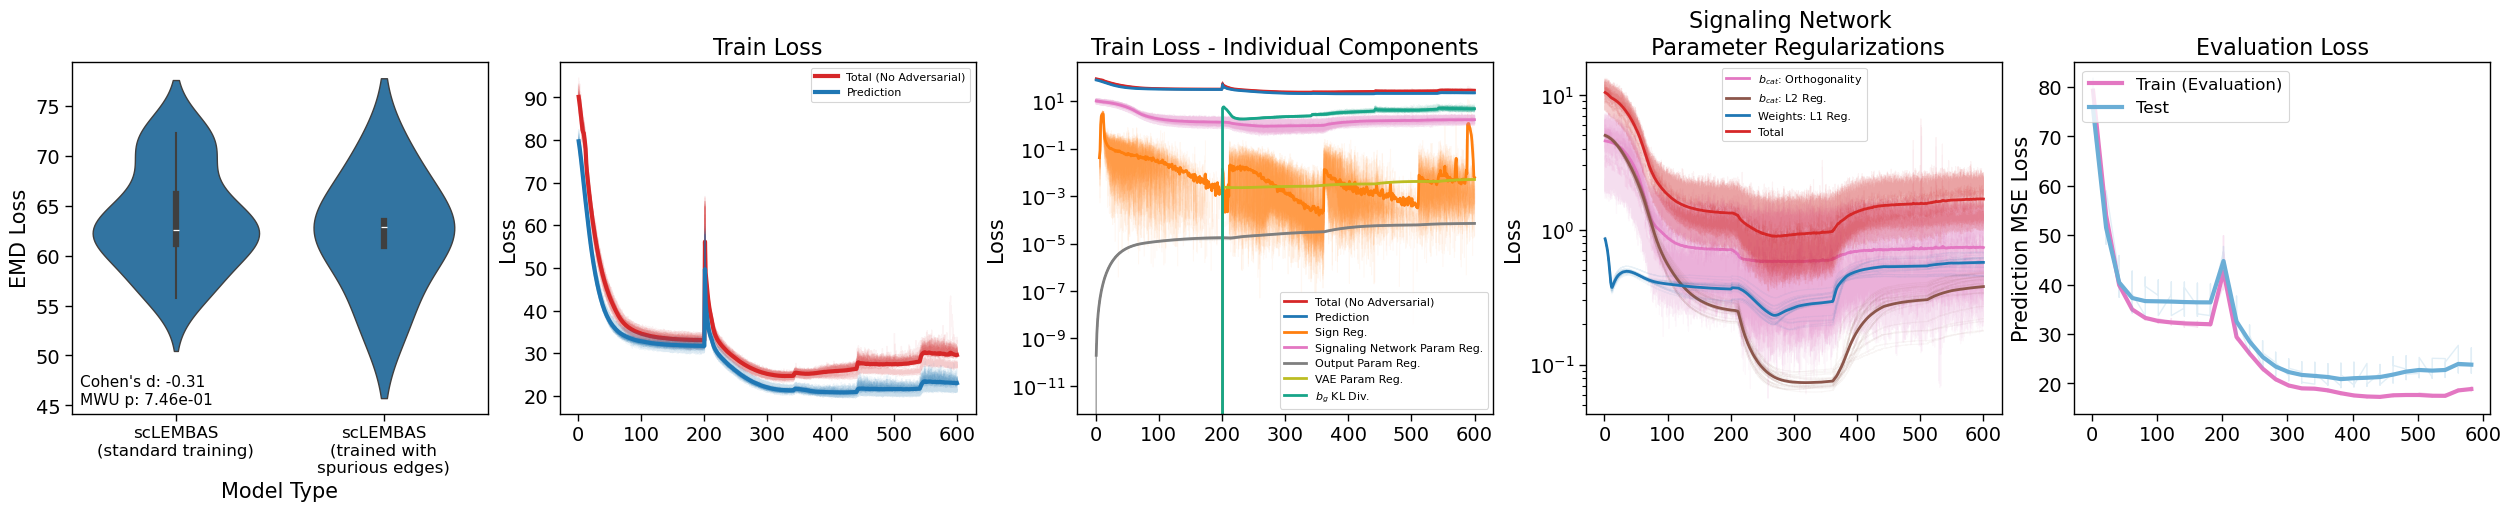

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(25, 5), constrained_layout=True)

# =======================
# Loss comparison
# =======================

j = 0
a = lr_no_stochastic['loss'].values
b = lr_stochastic['loss'].values

cd = cohens_d(a,b)
pval = stats.mannwhitneyu(a,b, alternative = 'two-sided').pvalue

sns.violinplot(data = loss_res, x = 'model_type', y = 'loss', ax = ax[j])
ax[j].set_xlabel('Model Type')
ax[j].set_ylabel('EMD Loss')
ax[j].tick_params(axis='x', labelsize=12)
annot_text = f"Cohen's d: {cd:.2f}\nMWU p: {pval:.2e}"
ax[j].text(
    0.02, 0.02, annot_text,
    transform=ax[j].transAxes,   # use axes coords (0–1)
    ha='left',                  # right-align text
    va='bottom',                 # anchor to bottom
    fontsize=11,
)


################## Training CURVES ##################
colors = [
    "#d62728", "#1f77b4", "#ff7f0e", "#2ca02c",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17a589", "#FFD700", "#ff9896",
]

df = train_stats_df.copy()
df['total_train_loss_no_adverserial'] = df[loss_cols_main].sum(axis=1)

runs = list(df.groupby(["fold", "ensemble_idx"]))




# =======================
# 1. prediction loss
# =======================
j += 1

loss_cols_sub = ['total_train_loss_no_adverserial', 'train_loss_prediction']
labels = ['Total (No Adversarial)', 'Prediction']

for k, (col, label) in enumerate(zip(loss_cols_sub, labels)):
    if col in zero_cols:
        continue
    color = colors[k]

    # faint individual runs
    for _, run_df in runs:
        run_df = run_df.sort_values("epoch")
        ax[j].plot(
            run_df["epoch"], run_df[col],
            color=color, alpha=0.05, linewidth=1
        )

    # mean
    mean_df = compute_mean(df, [col])
    ax[j].plot(
        mean_df["epoch"], mean_df[col],
        color=color, linewidth=3, label=label
    )

ax[j].legend(fontsize='small')
ax[j].set_title('Train Loss')
ax[j].set_ylabel('Loss')

# =======================
# 2. all losses
# =======================
j += 1

all_cols = ['total_train_loss_no_adverserial'] + loss_cols_main
mean_df = compute_mean(df, all_cols)

for k, col in enumerate(all_cols):
    if col in zero_cols:
        continue
    color = colors[k]

    for _, run_df in runs:
        run_df = run_df.sort_values("epoch")
        ax[j].plot(
            run_df["epoch"], run_df[col],
            color=color, alpha=0.05, linewidth=0.8
        )

    ax[j].plot(
        mean_df["epoch"], mean_df[col],
        color=color, linewidth=2, label=loss_map[col]
    )

ax[j].legend(fontsize='small')
ax[j].set_title('Train Loss - Individual Components')
ax[j].set_yscale('log')
ax[j].set_ylabel('Loss')


# =======================
# 3. signaling network regs
# =======================
j += 1

loss_cols = [
    'sn_param_reg_tot_loss',
    'sn_param_reg_weights_L2_loss',
    'sn_param_reg_weights_L1_loss',
    'sn_param_reg_weights_kl_divergence',
    'sn_param_reg_global_bias_L2_loss',
    'sn_param_reg_global_bias_L1_loss',
    'sn_param_reg_cat_bias_L2_loss',
    'sn_param_reg_cat_bias_L1_loss',
    'sn_param_reg_cat_bias_pert'
][::-1]

palette = [
    'tab:red', 
    'tab:blue', 'tab:blue', # can repeat because either L2 or L1 is present
    'tab:purple', 'tab:orange',
    'tab:cyan', 'tab:brown', 'tab:olive',
    (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)
][::-1]

loss_labels = {
    'sn_param_reg_tot_loss': 'Total',
    'sn_param_reg_weights_L2_loss': 'Weights: L2 Reg.',
    'sn_param_reg_weights_L1_loss': 'Weights: L1 Reg.',
    'sn_param_reg_weights_kl_divergence': 'Weights: KL Divergence',
    'sn_param_reg_global_bias_L2_loss': r'$b_g$: L2 Reg.',
    'sn_param_reg_global_bias_L1_loss': r'$b_g$: L1 Reg.',
    'sn_param_reg_cat_bias_L2_loss': r'$b_{cat}$: L2 Reg.',
    'sn_param_reg_cat_bias_L1_loss': r'$b_{cat}$: L1 Reg.',
    'sn_param_reg_cat_bias_pert': r'$b_{cat}$: Orthogonality'
}

mean_df = compute_mean(df, loss_cols)

for col, color in zip(loss_cols, palette):
    if col in zero_cols:
        continue

    for _, run_df in runs:
        run_df = run_df.sort_values("epoch")
        ax[j].plot(
            run_df["epoch"], run_df[col],
            color=color, alpha=0.05, linewidth=0.8
        )

    ax[j].plot(
        mean_df["epoch"], mean_df[col],
        color=color, linewidth=2, label=loss_labels[col]
    )

ax[j].set_title('Signaling Network \n Parameter Regularizations')
ax[j].set_yscale('log')
ax[j].legend(fontsize='small')
ax[j].set_ylabel('Loss')

# =======================
# 4. Evaluation Losses
# =======================
j += 1
palette = [
    "#e377c2",  # Pink
    "#6baed6",  # light blue
]

# keep original category order
loss_type_order = list(pd.unique(eval_df['loss_type']))
color_map = dict(zip(loss_type_order, palette[:len(loss_type_order)]))

# drop all-zero loss types, while preserving order/colors
zero_loss_types = [
    lt for lt in loss_type_order
    if np.all(eval_df.loc[eval_df['loss_type'] == lt, 'loss_full'].values == 0)
]
loss_type_order_plot = [lt for lt in loss_type_order if lt not in zero_loss_types]

runs = list(eval_df.groupby(['fold', 'ensemble_idx']))


for loss_type in loss_type_order_plot:
    color = color_map[loss_type]

    # individual ensemble/fold lines
    for _, run_df in runs:
        run_df_ = run_df[run_df['loss_type'] == loss_type].sort_values('epoch')
        if len(run_df_) == 0:
            continue
        ax[j].plot(
            run_df_['epoch'], run_df_['loss_full'],
            color=color, alpha=0.2, linewidth=1
        )

    # mean across folds + ensembles
    mean_df = (
        eval_df[eval_df['loss_type'] == loss_type]
        .groupby('epoch', as_index=False)['loss_full']
        .mean()
        .sort_values('epoch')
    )
    ax[j].plot(
        mean_df['epoch'], mean_df['loss_full'],
        color=color, linewidth=3, label=loss_type
    )

ax[j].set_title('Evaluation Loss')
ax[j].set_ylabel('Prediction MSE Loss')
ax[j].legend(title=None, loc='upper left')

plt.show()

The total loss curve starts higher, but ends in a similar range. The signaling network parameters total curve doesn't look substantially altered either.